# Análisis descriptivo de Spider 1.0 con anotaciones y esquemas

Este notebook estudia los pares pregunta-SQL de Spider y los vincula con los metadatos oficiales de los esquemas relacionales. La anotacion de cada ejemplo se obtiene de `xlangai/spider`; las definiciones de tablas, columnas, tipos, claves primarias y claves foraneas se incorporan desde el archivo `tables.json` del repositorio oficial de Spider, usando `db_id` como clave de union.

El análisis cubre procedencia y licencia, estructura de datos, variables, distribución por partición y base de datos, complejidad SQL, longitud de textos y caracteristicas de los esquemas. Las figuras se guardan en una carpeta junto a los datos del proyecto.


## 1. Fuente, licencia y alcance

Spider 1.0 es un conjunto de datos anotado por 11 estudiantes universitarios para la tarea Text-to-SQL, publicado por Yu et al. en EMNLP 2018. Las anotaciones públicas incluyen preguntas en lenguaje natural, consultas SQL de referencia y versiones tokenizadas. El conjunto de Hugging Face `xlangai/spider` ofrece los *splits* `train` y `validation` (equivalente al *development set* público), con 7.000 y 1.034 ejemplos, respectivamente.

Este notebook combina esas anotaciones con `tables.json` del repositorio oficial `taoyds/spider`. El archivo contiene un registro por base de datos y describe nombres originales y normalizados de tablas y columnas, tipos de columna, claves primarias y relaciones de clave foránea. La union se realiza mediante `db_id`; por tanto, cada pregunta puede analizarse junto con el esquema de su base.

La licencia indicada para Spider es **CC BY-SA 4.0**. Se debe citar el articulo original y respetar atribución y compartir igual en las redistribuciones. El conjunto oficial tiene un *test set* oculto, sin consultas de referencia públicas; por ello, este notebook analiza entrenamiento y validación, y no presenta la partición de validación como un test independiente.

**Fuentes:** [Hugging Face: xlangai/spider](https://huggingface.co/datasets/xlangai/spider), [repositorio oficial y documentación de Spider](https://github.com/taoyds/spider), [página oficial del benchmark](https://yale-lily.github.io/spider).


## 2. Carga de anotaciones y esquemas


In [34]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import json
import urllib.request
from collections import Counter
from wordcloud import WordCloud
from pathlib import Path

spider = load_dataset("xlangai/spider")

train = spider["train"].to_pandas().assign(split="train")
validation = spider["validation"].to_pandas().assign(split="validation")
df = pd.concat([train, validation], ignore_index=True)

# Metadatos oficiales del esquema Spider. Cada entrada se une por db_id.
TABLES_URL = "https://raw.githubusercontent.com/taoyds/spider/refs/heads/master/evaluation_examples/examples/tables.json"
with urllib.request.urlopen(TABLES_URL) as response:
    tables_data = json.load(response)
schemas = {schema["db_id"]: schema for schema in tables_data}

missing_schema_ids = sorted(set(df["db_id"]) - set(schemas))
if missing_schema_ids:
    raise ValueError(f"No se encontro schema para db_id: {missing_schema_ids}")

print(spider)
print("Dimensiones train:", train.shape)
print("Dimensiones validation:", validation.shape)
print("Dimensiones combinadas (anotaciones + split):", df.shape)
print("Bases con esquema oficial disponible:", len(schemas))
print("Bases presentes en train/validation:", df["db_id"].nunique())


DatasetDict({
    train: Dataset({
        features: ['db_id', 'query', 'question', 'query_toks', 'query_toks_no_value', 'question_toks'],
        num_rows: 7000
    })
    validation: Dataset({
        features: ['db_id', 'query', 'question', 'query_toks', 'query_toks_no_value', 'question_toks'],
        num_rows: 1034
    })
})
Dimensiones train: (7000, 7)
Dimensiones validation: (1034, 7)
Dimensiones combinadas (anotaciones + split): (8034, 7)
Bases con esquema oficial disponible: 166
Bases presentes en train/validation: 160


## 3. Estructura y variables

La tabla de ejemplos contiene las anotaciones y el identificador de base. `split` se agrega durante la carga para conservar la procedencia de cada registro. Los metadatos del esquema se almacenan en `schemas` y se resumen en una segunda tabla, `schema_summary`; no se duplican todos los objetos JSON en cada fila de preguntas.

| Variable | Tipo / formato | Significado |
|---|---|---|
| `db_id` | Texto | Identificador de la base de datos objetivo; enlaza el ejemplo con `tables.json`. |
| `question` | Texto | Pregunta en inglés anotada en lenguaje natural. |
| `query` | Texto | Consulta SQL de referencia (anotacion objetivo). |
| `query_toks` | Lista de textos | Consulta SQL segmentada en tokens. |
| `query_toks_no_value` | Lista de textos | SQL tokenizado con valores literales reemplazados por el marcador `value`. |
| `question_toks` | Lista de textos | Pregunta segmentada en tokens. |
| `split` | Texto | Particion del ejemplo: `train` o `validation`. Variable agregada en este notebook. |
| `table_names` / `table_names_original` | Listas de textos en `schemas` | Nombres de tablas normalizados y nombres originales del esquema. |
| `column_names` / `column_names_original` | Listas de pares `[indice_tabla, nombre]` | Columnas con su tabla asociada, en formato normalizado y original. El indice `-1` identifica la columna comodin `*`. |
| `column_types` | Lista de textos en `schemas` | Tipo semantico asignado a cada columna, por ejemplo `text`, `number`, `time`, `boolean` o `others`. |
| `primary_keys` | Lista de indices enteros | Indices de columna que representan claves primarias. |
| `foreign_keys` | Lista de pares de indices enteros | Relaciones entre columnas que representan claves foraneas. |
| `num_tables`, `num_columns`, `num_primary_keys`, `num_foreign_keys` | Enteros derivados | Conteos por base de tablas, columnas de usuario y claves. Se calculan desde `tables.json` y se anexan a cada ejemplo para el análisis. |

En la versión cargada se analizan 8.034 pares pregunta-SQL: 7.000 de entrenamiento y 1.034 de validación. El archivo oficial de esquemas incluye bases adicionales correspondientes a particiones no públicas en este conjunto cargado; las gráficas de esquemas se limitan a las bases enlazadas con train/validation.


In [35]:
# Resumen de tipos y valores faltantes en las anotaciones cargadas.
display(df.dtypes.to_frame("tipo"))
faltantes = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
})
display(faltantes)

# Resumen estructural por base de datos, excluyendo la columna comodin *.
def summarize_schema(schema):
    user_columns = [
        (idx, table_id, name)
        for idx, (table_id, name) in enumerate(schema["column_names"])
        if table_id >= 0 and name != "*"
    ]
    type_counts = Counter(
        schema["column_types"][idx]
        for idx, _, _ in user_columns
        if idx < len(schema["column_types"])
    )
    return {
        "db_id": schema["db_id"],
        "num_tables": len(schema["table_names"]),
        "num_columns": len(user_columns),
        "num_primary_keys": len(schema["primary_keys"]),
        "num_foreign_keys": len(schema["foreign_keys"]),
        "column_type_counts": dict(type_counts),
    }

schema_summary = pd.DataFrame(
    summarize_schema(schemas[db_id]) for db_id in sorted(df["db_id"].unique())
)

for column in ["num_tables", "num_columns", "num_primary_keys", "num_foreign_keys"]:
    counts = schema_summary.set_index("db_id")[column]
    df[column] = df["db_id"].map(counts)

print("Bases con esquema enlazado:", len(schema_summary))
display(schema_summary.drop(columns="column_type_counts").describe().round(2))


,tipo
db_id,str
query,str
question,str
query_toks,object
query_toks_no_value,object
question_toks,object
split,str


,faltantes,porcentaje
db_id,0,0.0
query,0,0.0
question,0,0.0
query_toks,0,0.0
query_toks_no_value,0,0.0
question_toks,0,0.0
split,0,0.0


Bases con esquema enlazado: 160


,num_tables,num_columns,num_primary_keys,num_foreign_keys
count,160.00,160.00,160.00,160.00
mean,5.11,26.82,4.54,4.64
std,3.74,31.16,3.22,4.75
min,2.00,6.00,0.00,0.00
25%,3.00,13.00,3.00,2.00
50%,4.00,19.00,3.00,3.00
75%,6.00,29.25,5.00,6.00
max,26.00,352.00,18.00,25.00


## 4. Estadisticas de las anotaciones

In [36]:
resumen = pd.DataFrame({
    "metrica": [
        "Ejemplos totales", "Ejemplos de entrenamiento", "Ejemplos de validacion",
        "Bases de datos en ejemplos", "Preguntas unicas", "Consultas SQL unicas"
    ],
    "valor": [
        len(df), len(train), len(validation), df["db_id"].nunique(),
        df["question"].nunique(), df["query"].nunique()
    ]
})
display(resumen)

# Longitudes por separacion de espacios: medida aproximada, no tokenizacion del modelo.
df["question_words"] = df["question"].fillna("").str.split().str.len()
df["sql_words"] = df["query"].fillna("").str.split().str.len()
df["question_chars"] = df["question"].fillna("").str.len()
df["sql_chars"] = df["query"].fillna("").str.len()
display(df[["question_words", "sql_words", "question_chars", "sql_chars"]].describe().round(2))


,metrica,valor
0,Ejemplos totales,8034
1,Ejemplos de entrenamiento,7000
2,Ejemplos de validacion,1034
3,Bases de datos en ejemplos,160
4,Preguntas unicas,7990
5,Consultas SQL unicas,4525


,question_words,sql_words,question_chars,sql_chars
count,8034.00,8034.00,8034.00,8034.00
mean,12.69,15.85,70.50,109.26
std,4.33,9.37,23.76,64.33
min,3.00,4.00,16.00,18.00
25%,10.00,9.00,54.00,62.00
50%,12.00,13.00,68.00,92.00
75%,15.00,21.00,85.00,146.00
max,39.00,87.00,224.00,577.00


En este análisis, contamos como **pregunta única** cada texto distinto de la columna `question` en todo el dataset, sin distinguir a qué base de datos pertenece. Esto es importante porque una misma pregunta puede aparecer asociada a bases de datos distintas; en ese caso, se cuenta una sola vez. El conteo permite identificar cuántos textos de pregunta diferentes hay en el conjunto completo, aunque algunos aparezcan en más de un ejemplo.

- Podemos ver también que hay mas preguntas únicas que consultas SQL lo qué significa que, al comparar los textos exactos en todo el conjunto, hay más formas distintas de redactar preguntas que formas distintas de escribir las consultas SQL: 7990 preguntas únicas frente a 4525 consultas únicas. Por lo tanto, al menos algunas preguntas diferentes están asociadas con el mismo texto SQL; por ejemplo, “¿cuántos empleados hay?” y “calcula el total de empleados” podrían corresponder a `SELECT COUNT(*) FROM employees`. Esto no implica necesariamente que las preguntas sean duplicadas: son textos distintos que pueden compartir una consulta. Además, como el conteo no distingue las bases de datos, una misma cadena SQL puede aparecer en bases distintas.

## 5. Preparacion y guardado de gráficas


In [37]:
# Las imagenes se guardan en Proyecto/Datos/graficas_spider_esquemas.
# Si el kernel ya se ejecuta desde Proyecto/Datos, se usa ese directorio.
DATA_DIR = Path("Proyecto/Datos")
if not DATA_DIR.is_dir():
    DATA_DIR = Path(".")
GRAPH_DIR = DATA_DIR / "graficas_spider_esquemas"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(filename):
    name = str(filename).removesuffix(".png")
    while name.endswith("_spider"):
        name = name[:-len("_spider")]
    path = GRAPH_DIR / f"{name}_spider.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Figura guardada en: {path.resolve()}")


### Distribución de ejemplos por base de datos

Figura guardada en: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_spider_esquemas\01_top_bases_datos_spider.png


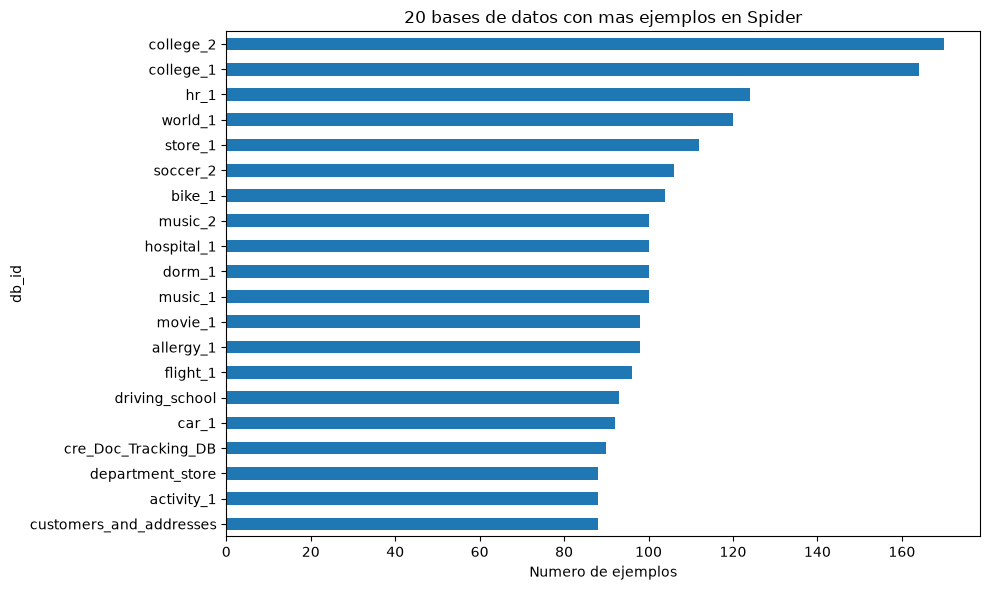

In [38]:
top_db = df["db_id"].value_counts().head(20)
plt.figure(figsize=(10, 6))
top_db.sort_values().plot(kind="barh")
plt.title("20 bases de datos con mas ejemplos en Spider")
plt.xlabel("Numero de ejemplos")
plt.ylabel("db_id")
plt.tight_layout()
save_figure("01_top_bases_datos")
plt.show()


### Frecuencia de construcciones SQL

,numero_de_consultas
AGREGACION,3821
JOIN,3179
GROUP BY,2052
ORDER BY,1865
LIMIT,1296
SUBCONSULTA,1178
DISTINCT,808
HAVING,506
INTERSECT,290
EXCEPT,240


Figura guardada en: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_spider_esquemas\02_construcciones_sql_spider.png


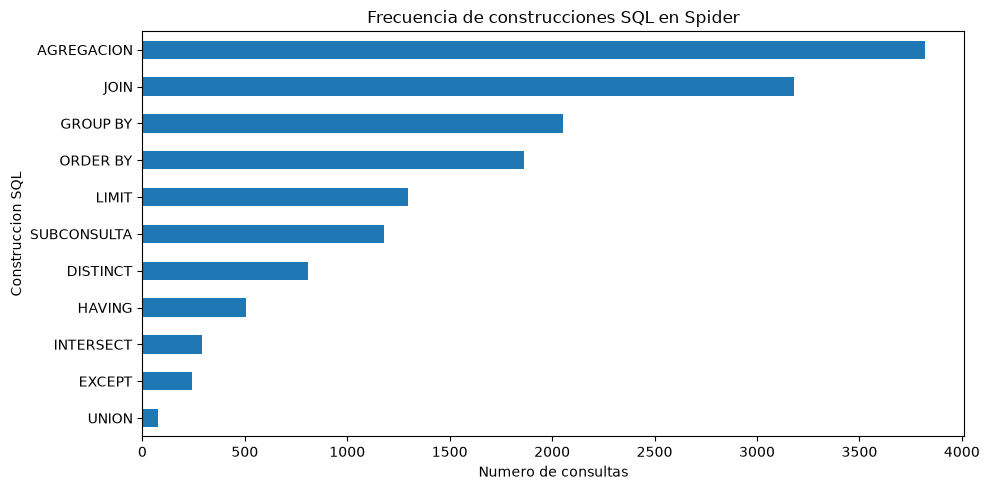

In [39]:
def sql_features(sql):
    s = str(sql).upper()
    return {
        "JOIN": bool(re.search(r"\bJOIN\b", s)),
        "GROUP BY": bool(re.search(r"\bGROUP\s+BY\b", s)),
        "ORDER BY": bool(re.search(r"\bORDER\s+BY\b", s)),
        "HAVING": bool(re.search(r"\bHAVING\b", s)),
        "DISTINCT": bool(re.search(r"\bDISTINCT\b", s)),
        "LIMIT": bool(re.search(r"\bLIMIT\b", s)),
        "UNION": bool(re.search(r"\bUNION\b", s)),
        "INTERSECT": bool(re.search(r"\bINTERSECT\b", s)),
        "EXCEPT": bool(re.search(r"\bEXCEPT\b", s)),
        "AGREGACION": bool(re.search(r"\b(COUNT|SUM|AVG|MIN|MAX)\s*\(", s)),
        "SUBCONSULTA": len(re.findall(r"\bSELECT\b", s)) > 1,
    }

sql_features_df = df["query"].apply(sql_features).apply(pd.Series)
sql_freq = sql_features_df.sum().sort_values(ascending=False)
display(sql_freq.to_frame("numero_de_consultas"))
plt.figure(figsize=(10, 5))
sql_freq.sort_values().plot(kind="barh")
plt.title("Frecuencia de construcciones SQL en Spider")
plt.xlabel("Numero de consultas")
plt.ylabel("Construccion SQL")
plt.tight_layout()
save_figure("02_construcciones_sql")
plt.show()


### Distribución de longitud de preguntas y consultas

Figura guardada en: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_spider_esquemas\03_longitud_preguntas_spider.png


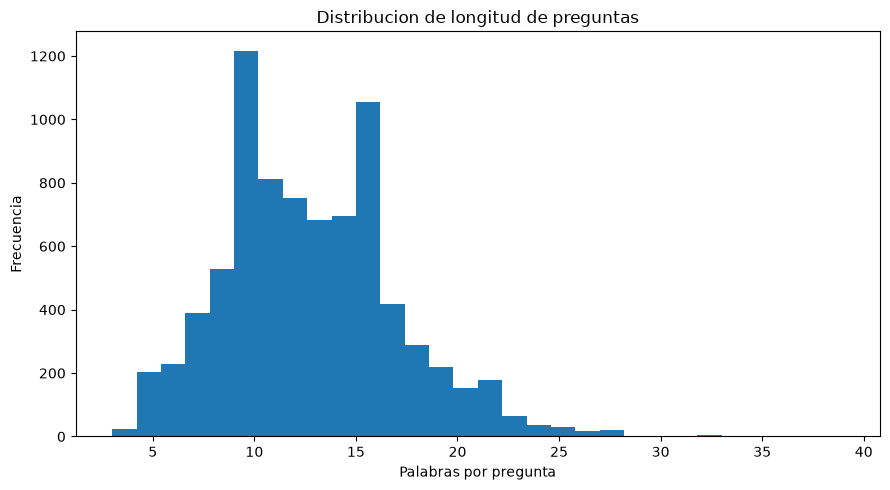

Figura guardada en: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_spider_esquemas\04_longitud_sql_spider.png


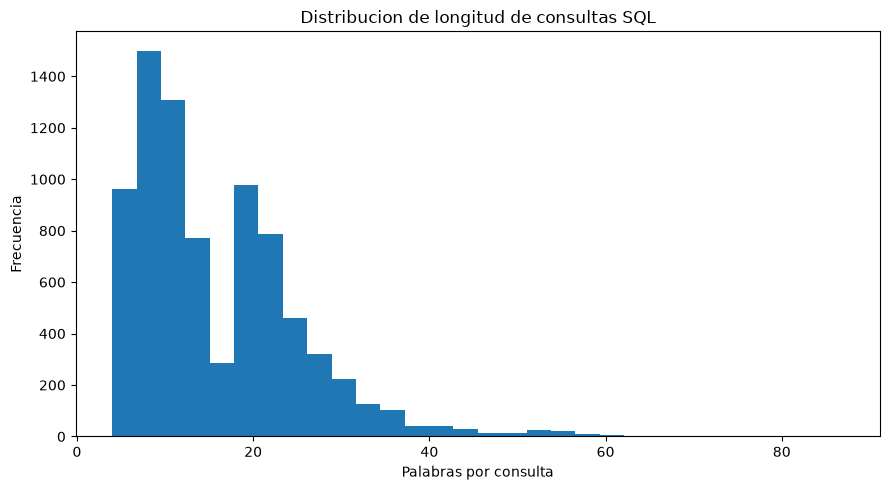

In [40]:
plt.figure(figsize=(9, 5))
plt.hist(df["question_words"], bins=30)
plt.title("Distribucion de longitud de preguntas")
plt.xlabel("Palabras por pregunta")
plt.ylabel("Frecuencia")
plt.tight_layout()
save_figure("03_longitud_preguntas")
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(df["sql_words"], bins=30)
plt.title("Distribucion de longitud de consultas SQL")
plt.xlabel("Palabras por consulta")
plt.ylabel("Frecuencia")
plt.tight_layout()
save_figure("04_longitud_sql")
plt.show()


### Relación entre longitud de pregunta y SQL

Figura guardada en: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_spider_esquemas\05_pregunta_vs_sql_spider.png


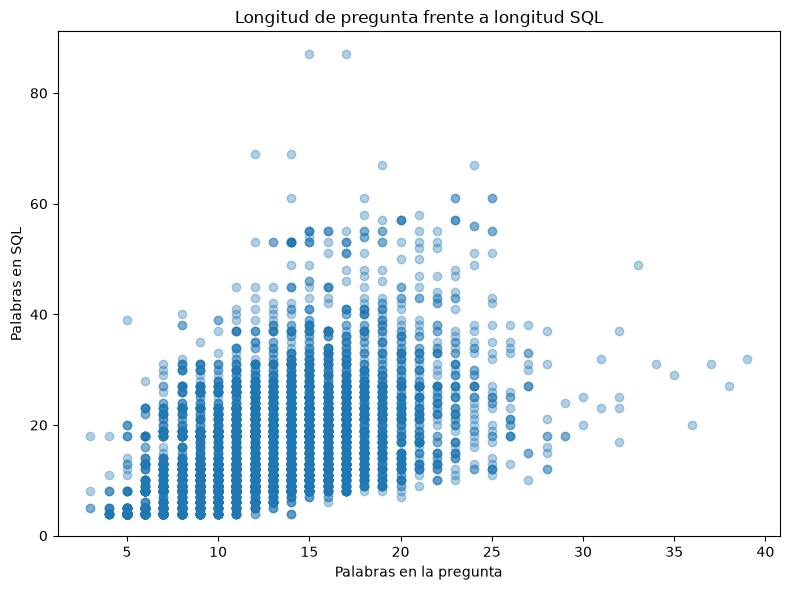

Correlacion de Pearson: 0.522


In [41]:
plt.figure(figsize=(8, 6))
plt.scatter(df["question_words"], df["sql_words"], alpha=0.35)
plt.title("Longitud de pregunta frente a longitud SQL")
plt.xlabel("Palabras en la pregunta")
plt.ylabel("Palabras en SQL")
plt.tight_layout()
save_figure("05_pregunta_vs_sql")
plt.show()
correlacion = df[["question_words", "sql_words"]].corr().iloc[0, 1]
print(f"Correlacion de Pearson: {correlacion:.3f}")


### Distribución de tamaño de los esquemas

Figura guardada en: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_spider_esquemas\06_tamano_esquemas_spider.png


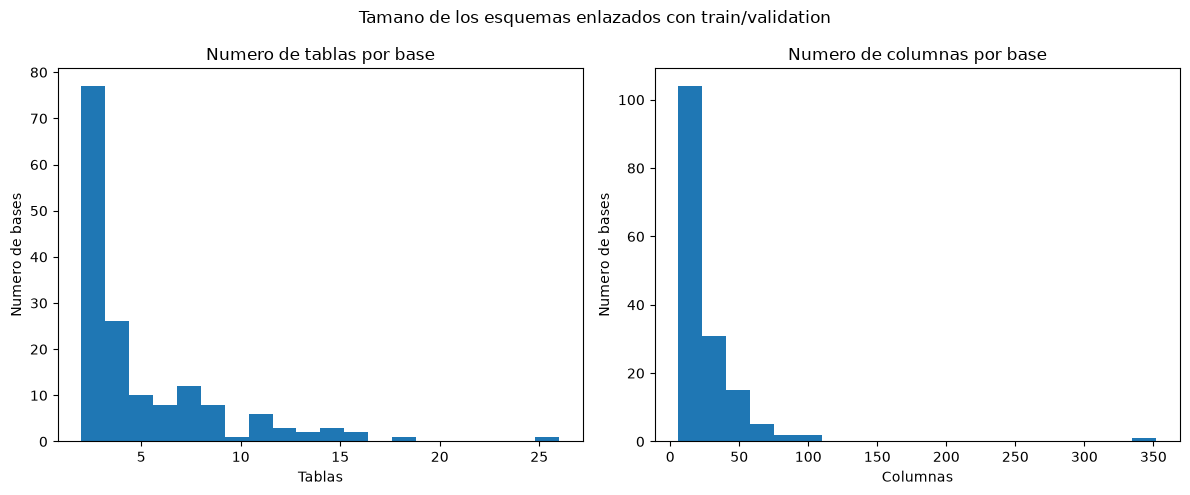

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(schema_summary["num_tables"], bins=20)
axes[0].set_title("Numero de tablas por base")
axes[0].set_xlabel("Tablas")
axes[0].set_ylabel("Numero de bases")
axes[1].hist(schema_summary["num_columns"], bins=20)
axes[1].set_title("Numero de columnas por base")
axes[1].set_xlabel("Columnas")
axes[1].set_ylabel("Numero de bases")
fig.suptitle("Tamano de los esquemas enlazados con train/validation")
fig.tight_layout()
save_figure("06_tamano_esquemas")
plt.show()


### Tipos de columna en los esquemas

,numero_de_columnas
number,2063
text,2000
time,215
others,8
boolean,5


Figura guardada en: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_spider_esquemas\07_tipos_columnas_spider.png


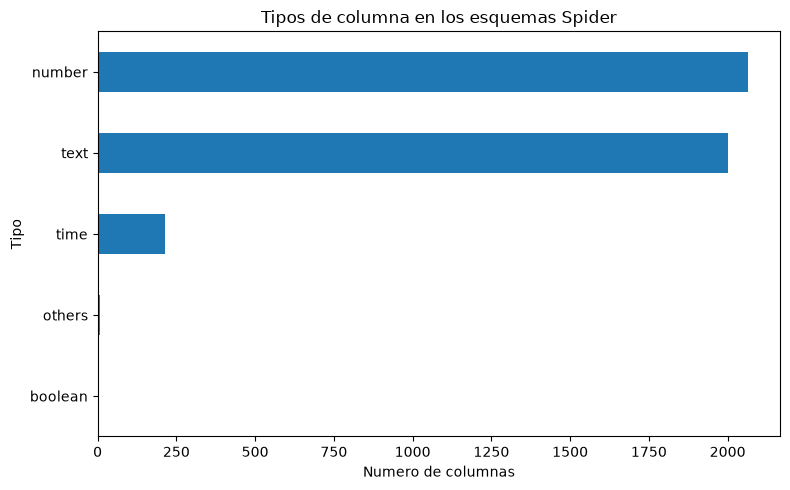

In [43]:
column_type_counts = Counter()
for type_counts in schema_summary["column_type_counts"]:
    column_type_counts.update(type_counts)
column_type_freq = pd.Series(column_type_counts).sort_values(ascending=False)
display(column_type_freq.to_frame("numero_de_columnas"))
plt.figure(figsize=(8, 5))
column_type_freq.sort_values().plot(kind="barh")
plt.title("Tipos de columna en los esquemas Spider")
plt.xlabel("Numero de columnas")
plt.ylabel("Tipo")
plt.tight_layout()
save_figure("07_tipos_columnas")
plt.show()


### Relaciones y claves dentro de los esquemas

El tamano de un esquema no muestra por si solo como se relacionan sus tablas. En esta seccion se analizan las claves primarias y foraneas descritas en `tables.json`. Para cada base se calcula cuantas relaciones de clave foranea tiene, que proporcion de sus tablas participa en esas relaciones y que porcentaje de sus columnas esta marcado como clave primaria o forma parte de una clave foranea. Estas metricas describen los metadatos del esquema, no la cantidad ni el contenido de las filas almacenadas en las bases.


,num_tables,num_columns,num_primary_keys,foreign_key_relationships,tables_with_foreign_keys,pct_tables_with_foreign_keys,key_columns,pct_columns_marked_as_keys
count,160.00,160.00,160.00,160.00,160.00,160.00,160.00,160.00
mean,5.11,26.82,4.54,4.64,4.89,96.43,8.52,33.59
std,3.74,31.16,3.22,4.75,3.48,13.37,7.27,12.37
min,2.00,6.00,0.00,0.00,0.00,0.00,2.00,6.52
25%,3.00,13.00,3.00,2.00,3.00,100.00,4.00,26.32
50%,4.00,19.00,3.00,3.00,3.00,100.00,5.50,31.18
75%,6.00,29.25,5.00,6.00,6.00,100.00,11.00,38.46
max,26.00,352.00,18.00,25.00,19.00,100.00,40.00,88.24


Esquema con más columnas: baseball_1 (352 columnas en 26 tablas)
Mayor número de relaciones de clave foránea: cre_Drama_Workshop_Groups (25 relaciones)
Mediana de tablas con al menos una clave foránea: 3.0
Figura guardada en: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_spider_esquemas\10_analisis_relacional_esquemas_spider.png


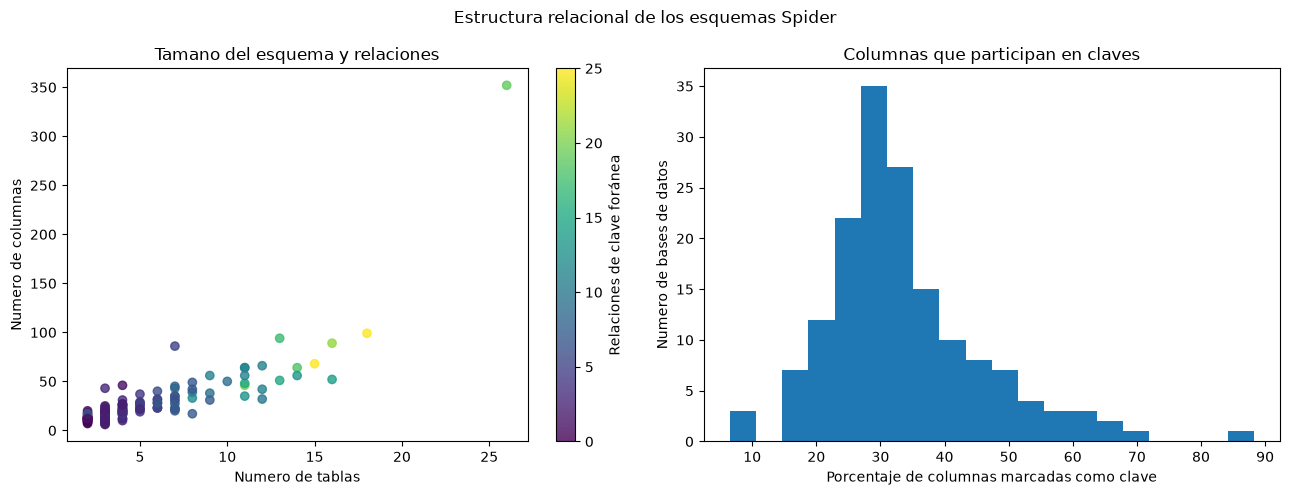

,db_id,num_tables,num_columns,num_primary_keys,foreign_key_relationships,tables_with_foreign_keys,pct_columns_marked_as_keys
73,hospital_1,15,68,15,25,15,52.94
34,cre_Drama_Workshop_Groups,18,99,18,25,18,40.40
121,sakila_1,16,89,16,21,15,39.33
22,college_2,11,46,11,20,10,65.22
6,baseball_1,26,352,0,19,19,6.53
5,assets_maintenance,14,64,10,18,14,43.75
68,formula_1,13,94,13,17,11,29.79
82,local_govt_and_lot,11,48,11,15,11,50.00
39,customer_deliveries,13,51,9,15,13,47.06
35,cre_Theme_park,16,52,16,14,16,46.15


In [44]:
# Relational metrics per schema from tables.json column indices.
# Las columnas * se excluyen del total, igual que en summarize_schema.
schema_metrics_rows = []
for db_id in sorted(df["db_id"].unique()):
    schema = schemas[db_id]
    user_column_indices = {
        idx for idx, (table_id, column_name) in enumerate(schema["column_names"])
        if table_id >= 0 and column_name != "*"
    }

    primary_key_indices = set()
    for key in schema["primary_keys"]:
        if isinstance(key, (list, tuple)):
            primary_key_indices.update(int(column_idx) for column_idx in key)
        else:
            primary_key_indices.add(int(key))

    foreign_keys = schema.get("foreign_keys", [])
    foreign_key_column_indices = set()
    tables_in_foreign_keys = set()
    for source_idx, target_idx in foreign_keys:
        for column_idx in (int(source_idx), int(target_idx)):
            foreign_key_column_indices.add(column_idx)
            if 0 <= column_idx < len(schema["column_names"]):
                table_id = schema["column_names"][column_idx][0]
                if table_id >= 0:
                    tables_in_foreign_keys.add(table_id)

    key_column_indices = (primary_key_indices | foreign_key_column_indices) & user_column_indices
    num_tables = len(schema["table_names"])
    num_columns = len(user_column_indices)
    schema_metrics_rows.append({
        "db_id": db_id,
        "foreign_key_relationships": len(foreign_keys),
        "tables_with_foreign_keys": len(tables_in_foreign_keys),
        "pct_tables_with_foreign_keys": (
            100 * len(tables_in_foreign_keys) / num_tables if num_tables else 0
        ),
        "key_columns": len(key_column_indices),
        "pct_columns_marked_as_keys": (
            100 * len(key_column_indices) / num_columns if num_columns else 0
        ),
    })

schema_analysis = schema_summary.merge(
    pd.DataFrame(schema_metrics_rows), on="db_id", how="left", validate="one_to_one"
)

metric_columns = [
    "num_tables", "num_columns", "num_primary_keys", "foreign_key_relationships",
    "tables_with_foreign_keys", "pct_tables_with_foreign_keys", "key_columns",
    "pct_columns_marked_as_keys"
]
display(schema_analysis[metric_columns].describe().round(2))

largest_schema = schema_analysis.loc[schema_analysis["num_columns"].idxmax()]
most_connected_schema = schema_analysis.loc[
    schema_analysis["foreign_key_relationships"].idxmax()
]
print(f"Esquema con más columnas: {largest_schema['db_id']} ({int(largest_schema['num_columns'])} columnas en {int(largest_schema['num_tables'])} tablas)")
print(f"Mayor número de relaciones de clave foránea: {most_connected_schema['db_id']} ({int(most_connected_schema['foreign_key_relationships'])} relaciones)")
print(f"Mediana de tablas con al menos una clave foránea: {schema_analysis['tables_with_foreign_keys'].median():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter = axes[0].scatter(
    schema_analysis["num_tables"], schema_analysis["num_columns"],
    c=schema_analysis["foreign_key_relationships"], cmap="viridis", alpha=0.8
)
axes[0].set_title("Tamano del esquema y relaciones")
axes[0].set_xlabel("Numero de tablas")
axes[0].set_ylabel("Numero de columnas")
fig.colorbar(scatter, ax=axes[0], label="Relaciones de clave foránea")
axes[1].hist(schema_analysis["pct_columns_marked_as_keys"], bins=20)
axes[1].set_title("Columnas que participan en claves")
axes[1].set_xlabel("Porcentaje de columnas marcadas como clave")
axes[1].set_ylabel("Numero de bases de datos")
fig.suptitle("Estructura relacional de los esquemas Spider")
fig.tight_layout()
save_figure("10_analisis_relacional_esquemas")
plt.show()

display(
    schema_analysis.sort_values("foreign_key_relationships", ascending=False)
    [["db_id", "num_tables", "num_columns", "num_primary_keys",
      "foreign_key_relationships", "tables_with_foreign_keys",
      "pct_columns_marked_as_keys"]]
    .head(10).round(2)
)


**Interpretacion.** La tabla resume las metricas de claves para las bases de datos analizadas. En el diagrama de dispersion, cada punto representa un esquema: su posicion indica el numero de tablas y columnas, y el color indica cuantas relaciones de clave foranea declara. El histograma muestra como varia la proporcion de columnas que intervienen en claves primarias o foraneas. Una mayor cantidad de relaciones puede senalar mas conexiones explicitas entre tablas, pero no mide por si misma la dificultad de una pregunta ni garantiza que todas las relaciones sean necesarias para una consulta. Las claves y los tipos del esquema aportan contexto util para el *schema linking*: localizar las tablas y columnas pertinentes para generar SQL. Los resultados se limitan a las bases que aparecen en los *splits* publicos cargados.


## 6. Vocabulario de las preguntas

Figura guardada en: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_spider_esquemas\08_nube_palabras_spider.png


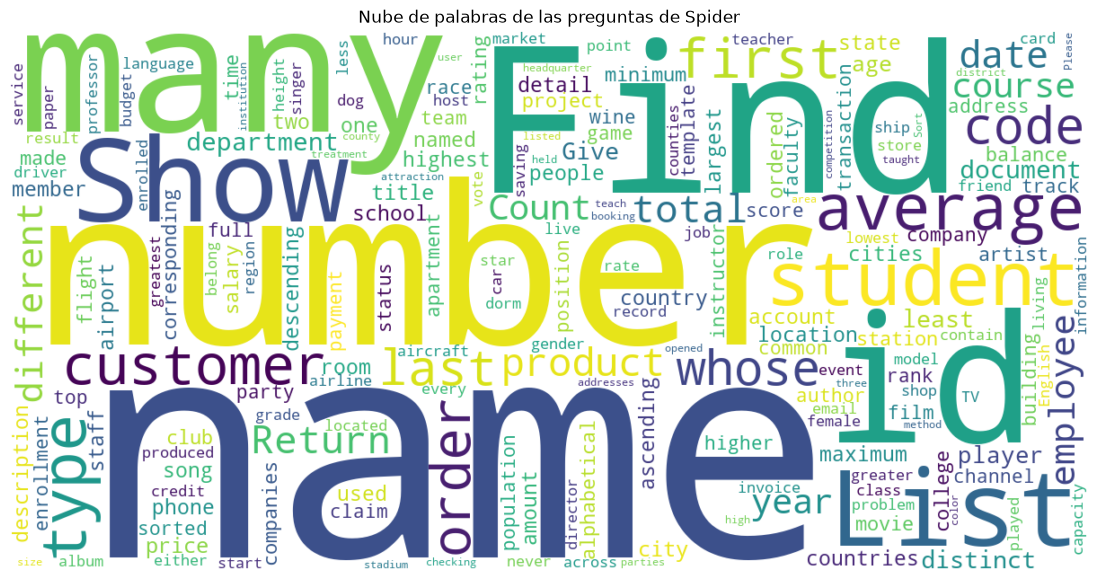

,palabra,frecuencia
0,name,1766
1,names,1738
2,number,1368
3,find,1238
4,show,898
5,each,801
6,list,738
7,most,694
8,average,588
9,students,537


Figura guardada en: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_spider_esquemas\09_frecuencia_palabras_spider.png


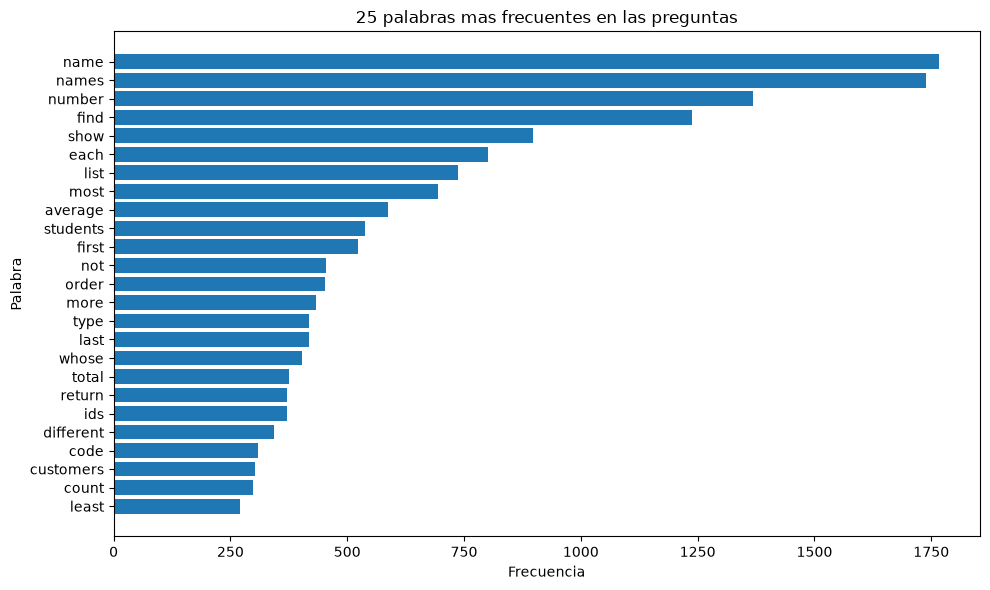

In [45]:
text_questions = " ".join(df["question"].dropna().astype(str))
wordcloud = WordCloud(width=1200, height=600, background_color="white", collocations=False).generate(text_questions)
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de las preguntas de Spider")
save_figure("08_nube_palabras")
plt.show()

stopwords = {
    "the", "a", "an", "of", "in", "on", "to", "and", "is", "are", "was", "were",
    "what", "which", "who", "how", "many", "for", "with", "from", "that", "have",
    "has", "do", "does", "all", "their", "than", "by", "be", "as", "there"
}
tokens = re.findall(r"[A-Za-z]+", text_questions.lower())
tokens = [token for token in tokens if token not in stopwords and len(token) > 2]
word_freq = Counter(tokens).most_common(25)
word_freq_df = pd.DataFrame(word_freq, columns=["palabra", "frecuencia"])
display(word_freq_df)
plt.figure(figsize=(10, 6))
plt.barh(word_freq_df["palabra"][::-1], word_freq_df["frecuencia"][::-1])
plt.title("25 palabras mas frecuentes en las preguntas")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.tight_layout()
save_figure("09_frecuencia_palabras")
plt.show()


## 7. Comparacion entre entrenamiento y validación

In [46]:
db_train = set(train["db_id"].unique())
db_validation = set(validation["db_id"].unique())
print("Bases en train:", len(db_train))
print("Bases en validation:", len(db_validation))
print("Bases compartidas:", len(db_train.intersection(db_validation)))
print("Bases solo en validation:", sorted(db_validation - db_train))
print("Filas por split:")
display(df["split"].value_counts().to_frame("ejemplos"))


Bases en train: 140
Bases en validation: 20
Bases compartidas: 0
Bases solo en validation: ['battle_death', 'car_1', 'concert_singer', 'course_teach', 'cre_Doc_Template_Mgt', 'dog_kennels', 'employee_hire_evaluation', 'flight_2', 'museum_visit', 'network_1', 'orchestra', 'pets_1', 'poker_player', 'real_estate_properties', 'singer', 'student_transcripts_tracking', 'tvshow', 'voter_1', 'world_1', 'wta_1']
Filas por split:


,ejemplos
split,
train,7000
validation,1034


## 8. Ejemplos cualitativos: pregunta, SQL y esquema

Se muestran los esquemas completos de las seis bases seleccionadas: un ejemplo principal y cinco ejemplos de otras bases. Cada esquema incluye todas sus tablas y columnas, tipos, marcas de claves primarias y de columnas que participan en relaciones de clave foránea, y todas las relaciones declaradas. Cada ejemplo conserva su `db_id`, pregunta y SQL de referencia.


In [47]:
from IPython.display import display, Markdown


def schema_completo(db_id):
    schema = schemas[db_id]
    table_names = schema["table_names_original"]
    table_columns = {table_id: [] for table_id in range(len(table_names))}

    primary_key_indices = set()
    for key in schema.get("primary_keys", []):
        if isinstance(key, (list, tuple)):
            primary_key_indices.update(int(column_idx) for column_idx in key)
        else:
            primary_key_indices.add(int(key))
    foreign_key_indices = set()
    for left_idx, right_idx in schema.get("foreign_keys", []):
        foreign_key_indices.update((int(left_idx), int(right_idx)))

    for idx, (table_id, column_name) in enumerate(schema["column_names_original"]):
        if table_id < 0 or column_name == "*":
            continue
        col_type = schema["column_types"][idx]
        markers = []
        if idx in primary_key_indices:
            markers.append("PK")
        if idx in foreign_key_indices:
            markers.append("FK")
        suffix = f" [{', '.join(markers)}]" if markers else ""
        table_columns[table_id].append(f"{column_name} ({col_type}){suffix}")

    table_ids = list(table_columns)
    lines = []
    for table_id in table_ids:
        columns = table_columns[table_id]
        lines.append(
            f"- {table_names[table_id]}: {', '.join(columns) if columns else '(sin columnas listadas)'}"
        )

    relations = []
    column_names = schema["column_names_original"]
    for left_idx, right_idx in schema.get("foreign_keys", []):
        left_table, left_column = column_names[int(left_idx)]
        right_table, right_column = column_names[int(right_idx)]
        relations.append(
            f"{table_names[left_table]}.{left_column} -> {table_names[right_table]}.{right_column}"
        )
    lines.append("Relaciones de claves foraneas: " + ("; ".join(relations) if relations else "ninguna declarada"))
    return "\n".join(lines)


# Mostrar una base con su esquema completo y ejemplos de otras bases.
main_example = df.sample(1, random_state=42).iloc[0]
main_db_id = main_example["db_id"]
main_schema = schemas[main_db_id]
main_column_count = sum(
    1 for table_id, name in main_schema["column_names"] if table_id >= 0 and name != "*"
)
display(Markdown(
    f"### Ejemplo detallado: `{main_db_id}`\n\n"
    f"**Particion:** {main_example['split']} | **Tablas:** {len(main_schema['table_names'])} | **Columnas en total:** {main_column_count}\n\n"
    f"**Pregunta:** {main_example['question']}\n\n"
    f"**SQL de referencia:**\n```sql\n{main_example['query']}\n```\n\n"
    f"**Esquema completo asociado:**\n\n{schema_completo(main_db_id)}"
))

other_dbs = df[df["db_id"] != main_db_id].drop_duplicates("db_id")
other_examples = other_dbs.sample(n=min(5, len(other_dbs)), random_state=42)
for _, example in other_examples.iterrows():
    db_id = example["db_id"]
    schema = schemas[db_id]
    column_count = sum(1 for table_id, name in schema["column_names"] if table_id >= 0 and name != "*")
    display(Markdown(
        f"### Ejemplo de otra base de datos: `{db_id}`\n\n"
        f"**Particion:** {example['split']} | **Tablas:** {len(schema['table_names'])} | **Columnas en total:** {column_count}\n\n"
        f"**Pregunta:** {example['question']}\n\n"
        f"**SQL de referencia:**\n```sql\n{example['query']}\n```\n\n"
        f"**Esquema completo asociado:**\n\n"
        f"{schema_completo(db_id)}"
    ))


### Ejemplo detallado: `tracking_orders`

**Particion:** train | **Tablas:** 7 | **Columnas en total:** 27

**Pregunta:** Find the ids of all the order items whose product id is 11.

**SQL de referencia:**
```sql
SELECT order_item_id FROM order_items WHERE product_id = 11
```

**Esquema completo asociado:**

- Customers: customer_id (number) [PK, FK], customer_name (text), customer_details (text)
- Invoices: invoice_number (number) [PK, FK], invoice_date (time), invoice_details (text)
- Orders: order_id (number) [PK, FK], customer_id (number) [FK], order_status (text), date_order_placed (time), order_details (text)
- Products: product_id (number) [PK, FK], product_name (text), product_details (text)
- Order_Items: order_item_id (number) [PK, FK], product_id (number) [FK], order_id (number) [FK], order_item_status (text), order_item_details (text)
- Shipments: shipment_id (number) [PK, FK], order_id (number) [FK], invoice_number (number) [FK], shipment_tracking_number (text), shipment_date (time), other_shipment_details (text)
- Shipment_Items: shipment_id (number) [FK], order_item_id (number) [FK]
Relaciones de claves foraneas: Orders.customer_id -> Customers.customer_id; Order_Items.product_id -> Products.product_id; Order_Items.order_id -> Orders.order_id; Shipments.invoice_number -> Invoices.invoice_number; Shipments.order_id -> Orders.order_id; Shipment_Items.shipment_id -> Shipments.shipment_id; Shipment_Items.order_item_id -> Order_Items.order_item_id

### Ejemplo de otra base de datos: `baseball_1`

**Particion:** train | **Tablas:** 26 | **Columnas en total:** 352

**Pregunta:** what is the full name and id of the college with the largest number of baseball players?

**SQL de referencia:**
```sql
SELECT T1.name_full ,  T1.college_id FROM college AS T1 JOIN player_college AS T2 ON T1.college_id  =  T2.college_id GROUP BY T1.college_id ORDER BY count(*) DESC LIMIT 1;
```

**Esquema completo asociado:**

- all_star: player_id (text) [FK], year (number), game_num (number), game_id (text), team_id (text), league_id (text), gp (number), starting_pos (number)
- appearances: year (number), team_id (text) [FK], league_id (text), player_id (text) [FK], g_all (number), gs (number), g_batting (number), g_defense (number), g_p (number), g_c (number), g_1b (number), g_2b (number), g_3b (number), g_ss (number), g_lf (number), g_cf (number), g_rf (number), g_of (number), g_dh (number), g_ph (number), g_pr (number)
- manager_award: player_id (text) [FK], award_id (text), year (number), league_id (text), tie (text), notes (number)
- player_award: player_id (text) [FK], award_id (text), year (number), league_id (text), tie (text), notes (text)
- manager_award_vote: award_id (text), year (number), league_id (text), player_id (text), points_won (number), points_max (number), votes_first (number)
- player_award_vote: award_id (text), year (number), league_id (text), player_id (text) [FK], points_won (number), points_max (number), votes_first (number)
- batting: player_id (text) [FK], year (number), stint (number), team_id (text), league_id (text), g (number), ab (number), r (number), h (number), double (number), triple (number), hr (number), rbi (number), sb (number), cs (number), bb (number), so (number), ibb (number), hbp (number), sh (number), sf (number), g_idp (number)
- batting_postseason: year (number), round (text), player_id (text) [FK], team_id (text) [FK], league_id (text), g (number), ab (number), r (number), h (number), double (number), triple (number), hr (number), rbi (number), sb (number), cs (number), bb (number), so (number), ibb (number), hbp (number), sh (number), sf (number), g_idp (number)
- player_college: player_id (text) [FK], college_id (text) [FK], year (number)
- fielding: player_id (text) [FK], year (number), stint (number), team_id (text), league_id (text), pos (text), g (number), gs (number), inn_outs (number), po (number), a (number), e (number), dp (number), pb (number), wp (number), sb (number), cs (number), zr (number)
- fielding_outfield: player_id (text) [FK], year (number), stint (number), glf (number), gcf (number), grf (number)
- fielding_postseason: player_id (text) [FK], year (number), team_id (text), league_id (text), round (text), pos (text), g (number), gs (number), inn_outs (number), po (number), a (number), e (number), dp (number), tp (number), pb (number), sb (number), cs (number)
- hall_of_fame: player_id (text) [FK], yearid (number), votedby (text), ballots (number), needed (number), votes (number), inducted (text), category (text), needed_note (text)
- home_game: year (number), league_id (text), team_id (text) [FK], park_id (text) [FK], span_first (text), span_last (text), games (number), openings (number), attendance (number)
- manager: player_id (text), year (number), team_id (text) [FK], league_id (text), inseason (number), g (number), w (number), l (number), rank (number), plyr_mgr (text)
- manager_half: player_id (text), year (number), team_id (text) [FK], league_id (text), inseason (number), half (number), g (number), w (number), l (number), rank (number)
- player: player_id (text) [FK], birth_year (number), birth_month (number), birth_day (number), birth_country (text), birth_state (text), birth_city (text), death_year (number), death_month (number), death_day (number), death_country (text), death_state (text), death_city (text), name_first (text), name_last (text), name_given (text), weight (number), height (number), bats (text), throws (text), debut (text), final_game (text), retro_id (text), bbref_id (text)
- park: park_id (text) [FK], park_name (text), park_alias (text), city (text), state (text), country (text)
- pitching: player_id (text), year (number), stint (number), team_id (text), league_id (text), w (number), l (number), g (number), gs (number), cg (number), sho (number), sv (number), ipouts (number), h (number), er (number), hr (number), bb (number), so (number), baopp (number), era (number), ibb (number), wp (number), hbp (number), bk (number), bfp (number), gf (number), r (number), sh (number), sf (number), g_idp (number)
- pitching_postseason: player_id (text), year (number), round (text), team_id (text), league_id (text), w (number), l (number), g (number), gs (number), cg (number), sho (number), sv (number), ipouts (number), h (number), er (number), hr (number), bb (number), so (number), baopp (text), era (number), ibb (number), wp (number), hbp (number), bk (number), bfp (number), gf (number), r (number), sh (number), sf (number), g_idp (number)
- salary: year (number), team_id (text), league_id (text), player_id (text), salary (number)
- college: college_id (text) [FK], name_full (text), city (text), state (text), country (text)
- postseason: year (number), round (text), team_id_winner (text), league_id_winner (text), team_id_loser (text), league_id_loser (text), wins (number), losses (number), ties (number)
- team: year (number), league_id (text), team_id (text) [FK], franchise_id (text), div_id (text), rank (number), g (number), ghome (number), w (number), l (number), div_win (text), wc_win (text), lg_win (text), ws_win (text), r (number), ab (number), h (number), double (number), triple (number), hr (number), bb (number), so (number), sb (number), cs (number), hbp (number), sf (number), ra (number), er (number), era (number), cg (number), sho (number), sv (number), ipouts (number), ha (number), hra (number), bba (number), soa (number), e (number), dp (number), fp (number), name (text), park (text), attendance (number), bpf (number), ppf (number), team_id_br (text), team_id_lahman45 (text), team_id_retro (text)
- team_franchise: franchise_id (text), franchise_name (text), active (text), na_assoc (text)
- team_half: year (number), league_id (text), team_id (text), half (number), div_id (text), div_win (text), rank (number), g (number), w (number), l (number)
Relaciones de claves foraneas: all_star.player_id -> player.player_id; appearances.player_id -> player.player_id; appearances.team_id -> team.team_id; manager_award.player_id -> player.player_id; player_award.player_id -> player.player_id; player_award_vote.player_id -> player.player_id; batting.player_id -> player.player_id; batting_postseason.team_id -> team.team_id; batting_postseason.player_id -> player.player_id; player_college.college_id -> college.college_id; player_college.player_id -> player.player_id; fielding.player_id -> player.player_id; fielding_outfield.player_id -> player.player_id; fielding_postseason.player_id -> player.player_id; hall_of_fame.player_id -> player.player_id; home_game.park_id -> park.park_id; home_game.team_id -> team.team_id; manager.team_id -> team.team_id; manager_half.team_id -> team.team_id

### Ejemplo de otra base de datos: `network_1`

**Particion:** validation | **Tablas:** 3 | **Columnas en total:** 7

**Pregunta:** How many high schoolers are there?

**SQL de referencia:**
```sql
SELECT count(*) FROM Highschooler
```

**Esquema completo asociado:**

- Highschooler: ID (number) [PK, FK], name (text), grade (number)
- Friend: student_id (number) [PK, FK], friend_id (number) [FK]
- Likes: student_id (number) [PK, FK], liked_id (number) [FK]
Relaciones de claves foraneas: Friend.friend_id -> Highschooler.ID; Friend.student_id -> Highschooler.ID; Likes.student_id -> Highschooler.ID; Likes.liked_id -> Highschooler.ID

### Ejemplo de otra base de datos: `school_bus`

**Particion:** train | **Tablas:** 3 | **Columnas en total:** 14

**Pregunta:** How many drivers are there?

**SQL de referencia:**
```sql
SELECT count(*) FROM driver
```

**Esquema completo asociado:**

- driver: Driver_ID (number) [PK, FK], Name (text), Party (text), Home_city (text), Age (number)
- school: School_ID (number) [PK, FK], Grade (text), School (text), Location (text), Type (text)
- school_bus: School_ID (number) [PK, FK], Driver_ID (number) [FK], Years_Working (number), If_full_time (others)
Relaciones de claves foraneas: school_bus.Driver_ID -> driver.Driver_ID; school_bus.School_ID -> school.School_ID

### Ejemplo de otra base de datos: `csu_1`

**Particion:** train | **Tablas:** 6 | **Columnas en total:** 23

**Pregunta:** Report the name of all campuses in Los Angeles county.

**SQL de referencia:**
```sql
SELECT campus FROM campuses WHERE county  =  "Los Angeles"
```

**Esquema completo asociado:**

- Campuses: Id (number) [PK, FK], Campus (text), Location (text), County (text), Year (number)
- csu_fees: Campus (number) [PK, FK], Year (number), CampusFee (number)
- degrees: Year (number) [PK], Campus (number) [FK], Degrees (number)
- discipline_enrollments: Campus (number) [PK, FK], Discipline (number), Year (number), Undergraduate (number), Graduate (number)
- enrollments: Campus (number) [PK, FK], Year (number), TotalEnrollment_AY (number), FTE_AY (number)
- faculty: Campus (number) [FK], Year (number), Faculty (number)
Relaciones de claves foraneas: csu_fees.Campus -> Campuses.Id; degrees.Campus -> Campuses.Id; discipline_enrollments.Campus -> Campuses.Id; enrollments.Campus -> Campuses.Id; faculty.Campus -> Campuses.Id

### Ejemplo de otra base de datos: `company_office`

**Particion:** train | **Tablas:** 3 | **Columnas en total:** 17

**Pregunta:** How many companies are there?

**SQL de referencia:**
```sql
SELECT count(*) FROM Companies
```

**Esquema completo asociado:**

- buildings: id (number) [PK, FK], name (text), City (text), Height (number), Stories (number), Status (text)
- Companies: id (number) [PK, FK], name (text), Headquarters (text), Industry (text), Sales_billion (number), Profits_billion (number), Assets_billion (number), Market_Value_billion (text)
- Office_locations: building_id (number) [PK, FK], company_id (number) [FK], move_in_year (number)
Relaciones de claves foraneas: Office_locations.company_id -> Companies.id; Office_locations.building_id -> buildings.id

## Análisis e interpretacion de las gráficas

El conjunto analizado contiene 8.034 ejemplos públicos: 7.000 para entrenamiento y 1.034 para validación. Sus anotaciones combinan la pregunta, la consulta SQL y representaciones tokenizadas; la union con `tables.json` agrega contexto estructural de los esquemas a traves de `db_id`.

- **Distribución por base:** la grafica de las 20 bases con más ejemplos muestra que la cantidad de preguntas por dominio no es uniforme. Esto ayuda a detectar bases sobrerrepresentadas y a interpretar con cautela las métricas agregadas.
- **Construcciones SQL:** los conteos permiten observar la presencia de agregaciones, uniones, filtros, agrupamientos, ordenamientos y subconsultas. Una consulta puede contener varias construcciones, por lo que estos conteos no son categorias excluyentes.
- **Longitud y relación pregunta-SQL:** los histogramas describen la variabilidad de las solicitudes y las consultas. La dispersion y la correlacion resumen su asociacion, pero no miden por si solas la dificultad semántica ni el acierto de un modelo.
- **Tamano y tipos de esquemas:** las distribuciones por número de tablas y columnas cuantifican la variación estructural entre bases. El grafico de tipos de columna muestra la composicion de los esquemas disponibles y sirve para caracterizar la informacion que un sistema puede necesitar para vincular menciones de la pregunta con columnas.
- **Vocabulario:** la nube y el grafico de palabras frecuentes resumen terminos recurrentes en las preguntas. Son herramientas exploratorias; las frecuencias no identifican intenciones ni relaciones entre entidades por si solas.
- **Generalizacion entre esquemas:** en Spider, las bases asignadas a entrenamiento y validación no se comparten. Por ello, la validación permite examinar generalizacion a esquemas no vistos durante el entrenamiento, que es una propiedad central del benchmark.

Las gráficas deben leerse como una caracterizacion descriptiva del conjunto. Para evaluar un modelo se requiere, ademas, medir la calidad de SQL generado con los procedimientos de evaluación de Spider. El *test set* oficial tiene anotaciones de referencia ocultas y no se reconstruye ni se sustituye con la partición de validación en este notebook.


## 9. Justificacion del uso de Spider con esquemas

Spider es apropiado para estudiar Text-to-SQL porque cada ejemplo público relaciona una pregunta en lenguaje natural con una consulta de referencia y un identificador de base de datos. Al incorporar `tables.json`, el análisis y los experimentos pueden condicionar la generación al esquema correcto e investigar *schema linking*: la correspondencia entre expresiones de la pregunta y tablas o columnas.

La separación por bases entre entrenamiento y validación permite estudiar la generalizacion a esquemas no vistos. Los metadatos de claves y tipos tambien hacen posible analizar relaciones entre tablas y estructura de los datos, no solo la sintaxis de las consultas. Para resultados comparables con el benchmark, se debe mantener la partición oficial y aplicar sus métricas de evaluación.


## Referencias

- Yu, T. et al. (2018). *Spider: A Large-Scale Human-Labeled Dataset for Complex and Cross-Domain Semantic Parsing and Text-to-SQL Task*. EMNLP.
- [Dataset Spider en Hugging Face](https://huggingface.co/datasets/xlangai/spider).
- [Repositorio oficial de Spider y documentación de `tables.json`](https://github.com/taoyds/spider).
- [Sitio oficial del benchmark](https://yale-lily.github.io/spider).
